In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(42000, 785)

In [5]:
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [8]:
import matplotlib.pyplot as plt

In [7]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
4907,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


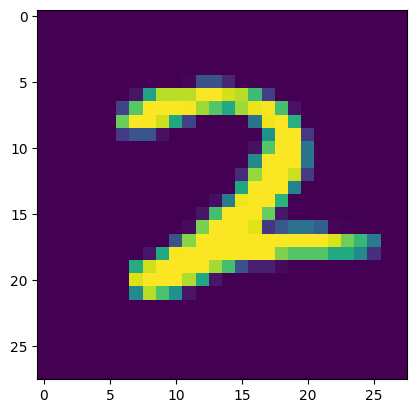

In [14]:
plt.imshow(df.iloc[4907, 1:].values.reshape(28, 28))

In [15]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [16]:
x

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
y

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [19]:
X_train.shape

(33600, 784)

In [20]:
X_test.shape

(8400, 784)

In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

KNeighborsClassifier()

In [23]:
y_pred = knn.predict(X_test)

In [24]:
y_pred

array([3, 6, 9, ..., 2, 7, 2])

In [25]:
from sklearn.metrics import accuracy_score

In [26]:
accuracy_score(y_test,y_pred)

0.9680952380952381

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [29]:
# Applying PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=100)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [30]:
X_train_trf.shape

(33600, 100)

In [31]:
knn = KNeighborsClassifier()

knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [36]:
y_pred_trf = knn.predict(X_test_trf)

In [37]:
y_pred_trf

array([3, 6, 9, ..., 2, 7, 2])

In [38]:
accuracy_score(y_test,y_pred_trf)

0.971547619047619

In [40]:
from sklearn.metrics import accuracy_score

for i in range(1, 785):

    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()
    knn.fit(X_train_trf, y_train)

    y_pred_trf = knn.predict(X_test_trf)

    print(f"Components: {i}, Accuracy: {accuracy_score(y_test, y_pred_trf)}")

    

Components: 1, Accuracy: 0.2727380952380952
Components: 2, Accuracy: 0.4255952380952381
Components: 3, Accuracy: 0.4913095238095238
Components: 4, Accuracy: 0.6204761904761905
Components: 5, Accuracy: 0.7446428571428572
Components: 6, Accuracy: 0.8229761904761905
Components: 7, Accuracy: 0.871904761904762
Components: 8, Accuracy: 0.8997619047619048
Components: 9, Accuracy: 0.9126190476190477
Components: 10, Accuracy: 0.9261904761904762
Components: 11, Accuracy: 0.935952380952381
Components: 12, Accuracy: 0.9425
Components: 13, Accuracy: 0.9482142857142857
Components: 14, Accuracy: 0.9520238095238095
Components: 15, Accuracy: 0.9547619047619048
Components: 16, Accuracy: 0.9603571428571429
Components: 17, Accuracy: 0.9620238095238095
Components: 18, Accuracy: 0.9638095238095238
Components: 19, Accuracy: 0.965
Components: 20, Accuracy: 0.9651190476190477
Components: 21, Accuracy: 0.9665476190476191
Components: 22, Accuracy: 0.9676190476190476
Components: 23, Accuracy: 0.9682142857142857
C

KeyboardInterrupt: 

In [41]:
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)


In [42]:
X_train_trf

array([[ 506.51671551, -411.1390416 ],
       [ 977.43793737, -344.04482642],
       [ -84.74961843, -547.48846946],
       ...,
       [-277.81804956, -679.28448867],
       [1487.59082689,  239.02223581],
       [-316.20326797, -651.34281322]])

In [45]:
import plotly.express as px
y_train_trf = y_train.astype(str)

fig = px.scatter(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10,
    labels={
        "x": "Principal Component 1",
        "y": "Principal Component 2",
        "color": "Digit"
    },
    title="MNIST after PCA"
)

fig.show()

In [46]:
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)


In [47]:
X_train_trf

array([[ 506.51671551, -411.1390416 , -120.0601967 ],
       [ 977.43793737, -344.04482642,  -94.94957643],
       [ -84.74961843, -547.48846946,  450.27660771],
       ...,
       [-277.81804956, -679.28448867,  661.77202231],
       [1487.59082689,  239.02223581, -325.81434662],
       [-316.20326797, -651.34281322,  238.47673691]])

In [49]:
fig = px.scatter_3d(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    z=X_train_trf[:, 2],
    color=y_train.astype(str),
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_layout(
    title="MNIST - PCA 3D",
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3"
    )
)

fig.show()

In [51]:
pca.explained_variance_ # tell us the eigen value of all pca

array([334619.59129145, 244331.83783354, 212179.77180973])

In [54]:
pca.components_.shape # tell us eigen vector means direction of our pricnipal direction

(3, 784)

In [56]:
pca.explained_variance_ratio_

array([0.09745105, 0.0711566 , 0.06179298])

In [57]:
# Now finding optimum number to get maximum like 90% we want ovarll varience to capture 

pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [58]:
X_train_trf.shape

(33600, 784)

In [59]:
pca.explained_variance_.shape

(784,)

In [61]:
pca.components_.shape

(784, 784)

In [64]:

np.cumsum(pca.explained_variance_ratio_)  # now cummulative sum and check which pca no giving us 90% varience

array([0.09745105, 0.16860765, 0.23040063, 0.28416826, 0.33311259,
       0.37595564, 0.40866469, 0.43759187, 0.46526248, 0.48876298,
       0.50981131, 0.53048713, 0.54764908, 0.5646408 , 0.58048814,
       0.59527177, 0.608467  , 0.6213026 , 0.63315648, 0.64464592,
       0.65535124, 0.66550064, 0.67512215, 0.68428049, 0.693158  ,
       0.70151793, 0.70963197, 0.71742228, 0.72484795, 0.73170789,
       0.73832765, 0.7446999 , 0.75072505, 0.75662971, 0.7622855 ,
       0.76766477, 0.77277392, 0.7776613 , 0.78241443, 0.78707079,
       0.7915929 , 0.79603242, 0.80023236, 0.8042095 , 0.8080525 ,
       0.81179644, 0.81540521, 0.81891249, 0.82227889, 0.8254924 ,
       0.82867603, 0.83175568, 0.83469255, 0.83756093, 0.84037963,
       0.84308765, 0.84574518, 0.84831713, 0.85085521, 0.85332527,
       0.85572893, 0.85812207, 0.86039399, 0.86261899, 0.86475495,
       0.86679668, 0.86882479, 0.87078658, 0.8727235 , 0.8746059 ,
       0.87647786, 0.87830156, 0.88006991, 0.8817943 , 0.88346

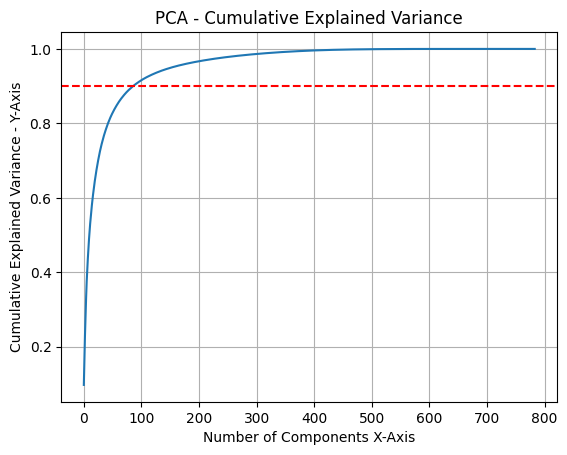

In [70]:
# with ploting the graph you can find at which pca no you get 90% var which is the target

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components X-Axis")
plt.ylabel("Cumulative Explained Variance - Y-Axis")
plt.title("PCA - Cumulative Explained Variance")
plt.axhline(y=0.90, color='r', linestyle='--')
plt.grid()
plt.show()

In [85]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("pca", PCA(n_components=100)),
    ("knn", KNeighborsClassifier())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.971547619047619


In [89]:
X_train.shape

(33600, 784)

In [86]:
y_pred_trf

array([3, 6, 9, ..., 2, 7, 2])

In [87]:
accuracy_score(y_test,y_pred_trf)

0.971547619047619

In [88]:
import pickle

pickle.dump(pipeline, open("model1.pkl", "wb"))


In [77]:
import os

print(os.getcwd())

/kaggle/working


In [78]:
os.listdir("/kaggle/working")

['.virtual_documents', 'knn.pkl', 'pca.pkl']

In [84]:
X_train.shape

(33600, 784)

In [90]:
print(X_train.min())
print(X_train.max())

pixel0      0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 784, dtype: int64
pixel0       0
pixel1       0
pixel2       0
pixel3       0
pixel4       0
            ..
pixel779    62
pixel780     0
pixel781     0
pixel782     0
pixel783     0
Length: 784, dtype: int64
